In [25]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import sys
import os
from pprint import pprint
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

#for local
sys.path.append("/home/ubuntu/m15kh/own/proj/Generator/src")
from process.preprocess import extract_video_frames
# from process.posprocess import generate_segmented_video_with_audio

using device: cuda


In [3]:
video_file = "/home/ubuntu/m15kh/own/proj/Generator/experiments/sam2/Sequence 02.mp4"
video_info = extract_video_frames(video_file)
print(video_info)


Video properties: 425 frames, 25.00 FPS, 1920x1080 resolution


Extracted 100/425 frames...
Extracted 200/425 frames...
Extracted 300/425 frames...
Extracted 400/425 frames...
Extracted 425 frames to 'frames'
{'fps': 25.0, 'width': 1920, 'height': 1080, 'frame_count': 425}


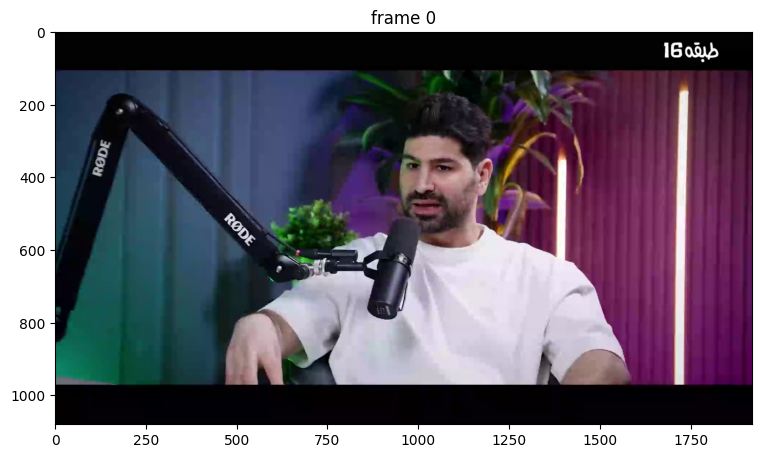

In [4]:

video_dir = "frames/"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

In [5]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "/home/ubuntu/m15kh/own/proj/Generator/experiments/sam2/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)
inference_state = predictor.init_state(video_path=video_dir)
predictor.reset_state(inference_state)

frame loading (JPEG):   0%|          | 0/425 [00:00<?, ?it/s]

frame loading (JPEG): 100%|██████████| 425/425 [00:16<00:00, 26.19it/s]


In [6]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

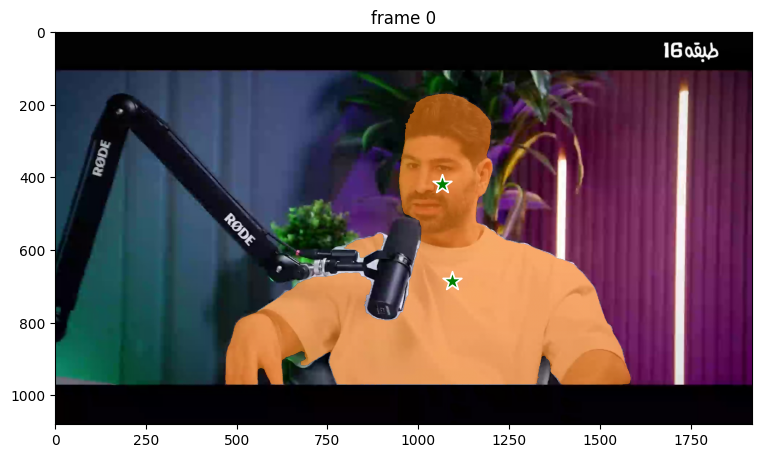

In [7]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integers)

# Let's add a 2nd positive click at (x, y) = (250, 220) to refine the mask
# sending all clicks (and their labels) to `add_new_points_or_box`
points = np.array([[1092, 685], [1065, 417]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([1, 1], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

propagate in video: 100%|██████████| 425/425 [00:38<00:00, 11.14it/s]


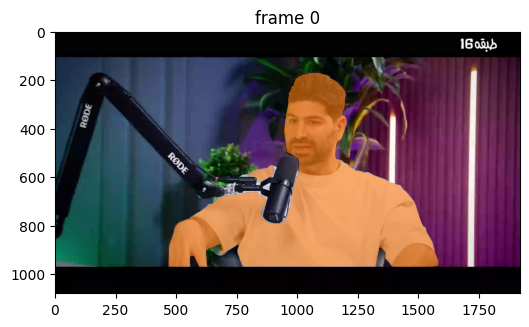

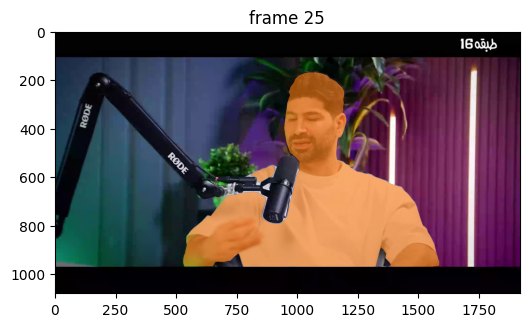

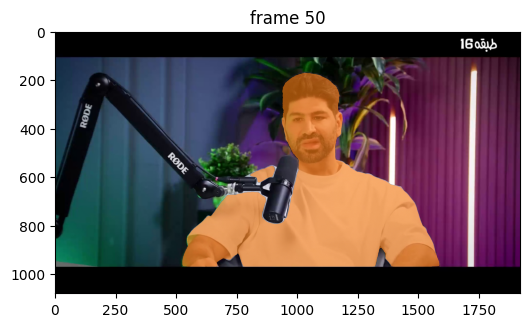

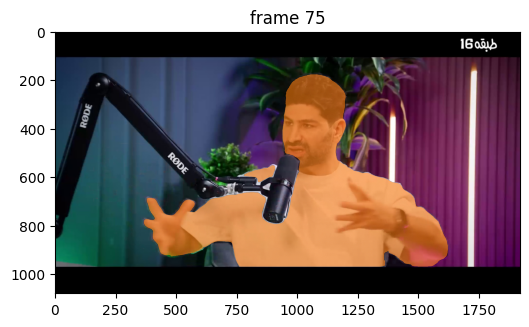

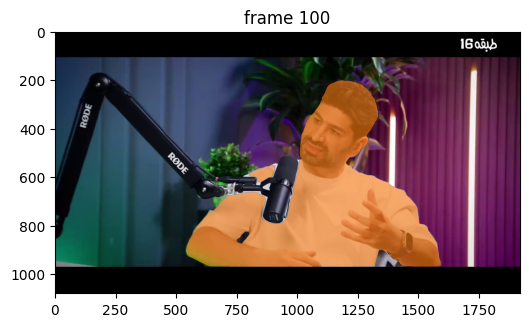

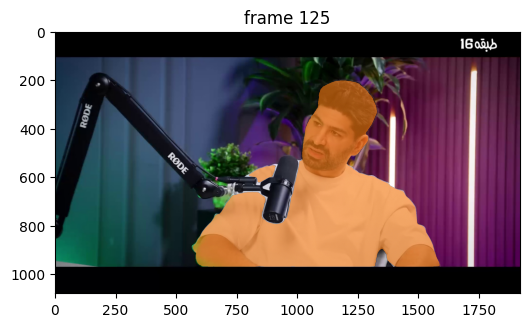

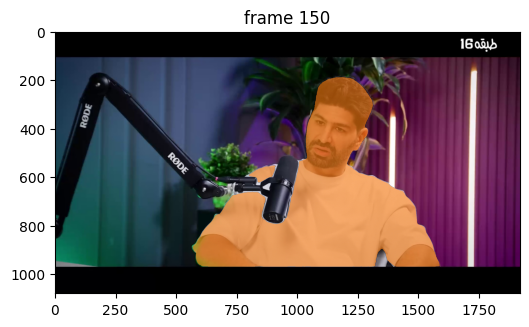

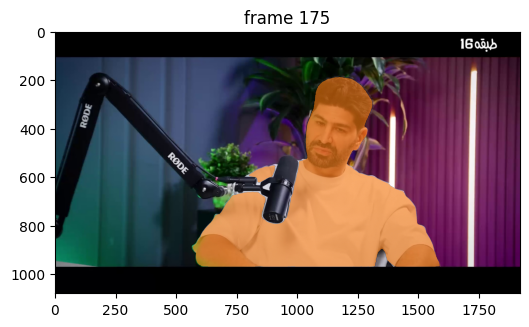

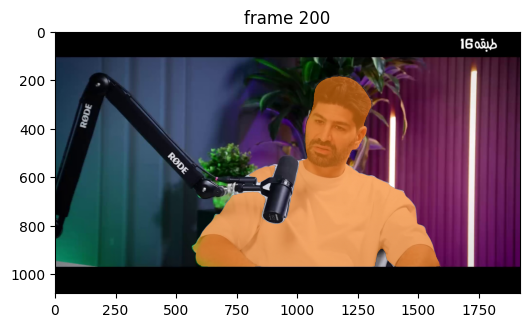

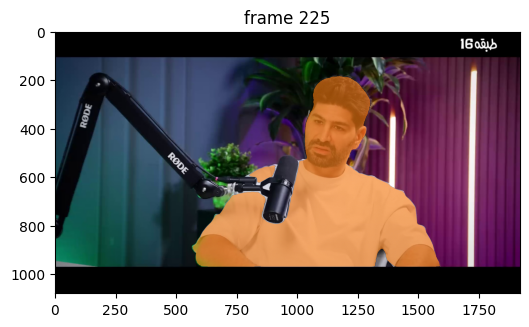

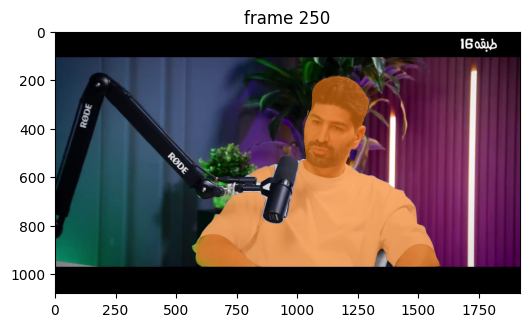

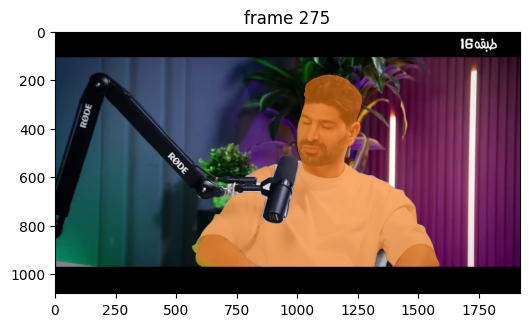

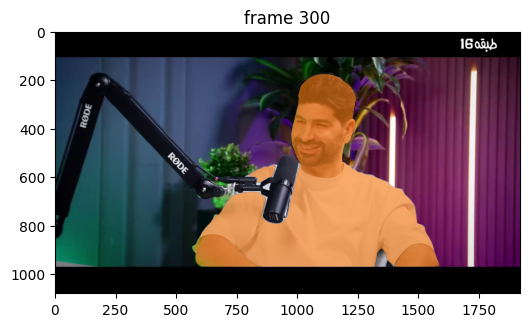

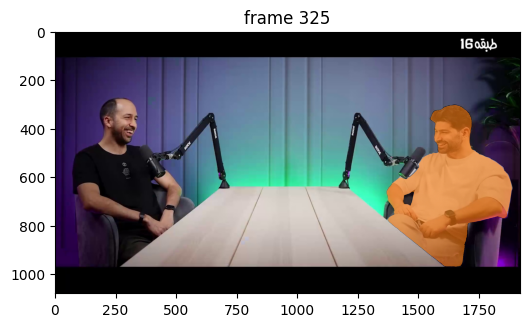

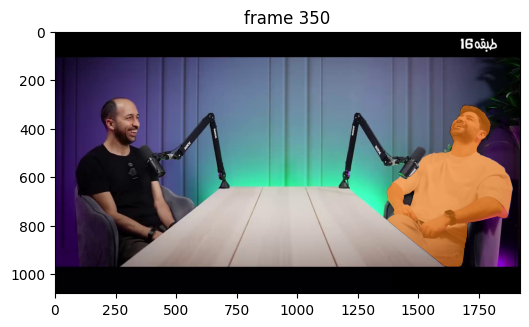

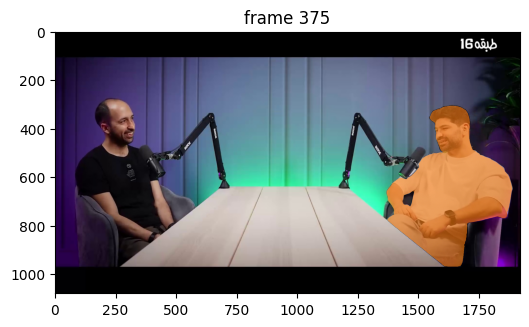

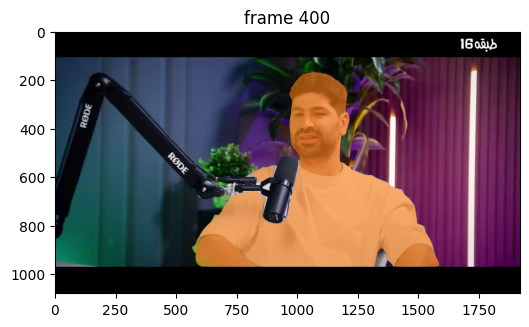

In [13]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 25
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

In [ ]:
# Add negative prompt if needed (uncomment to use)
# ann_frame_idx = 150  # further refine some details on this frame
# ann_obj_id = 1  # give a unique id to the object we interact with (it can be any integers)

# # show the segment before further refinement
# plt.figure(figsize=(9, 6))
# plt.title(f"frame {ann_frame_idx} -- before refinement")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
# show_mask(video_segments[ann_frame_idx][ann_obj_id], plt.gca(), obj_id=ann_obj_id)

# # Let's add a negative click on this frame to refine the segment
# points = np.array([[82, 410]], dtype=np.float32)
# # for labels, `1` means positive click and `0` means negative click
# labels = np.array([0], np.int32)
# _, _, out_mask_logits = predictor.add_new_points_or_box(
#     inference_state=inference_state,
#     frame_idx=ann_frame_idx,
#     obj_id=ann_obj_id,
#     points=points,
#     labels=labels,
# )

# # show the segment after the further refinement
# plt.figure(figsize=(9, 6))
# plt.title(f"frame {ann_frame_idx} -- after refinement")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
# show_points(points, labels, plt.gca())
# show_mask((out_mask_logits > 0.0).cpu().numpy(), plt.gca(), obj_id=ann_obj_id)

In [27]:
pprint(video_segments)

{0: {1: array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(1, 1080, 1920))},
 1: {1: array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(1, 1080, 1920))},
 2: {1: array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, 

In [39]:
def generate_segmented_video(input_video_path, output_video_path, video_segments, alpha=0.5):
    """
    Generate a segmented video by overlaying masks on the original video frames.
    
    Parameters:
    -----------
    input_video_path : str
        Path to the input video file
    output_video_path : str
        Path where the output video will be saved
    video_segments : dict
        Dictionary mapping frame indices to segmentation masks
        Format: {frame_idx: {obj_id: mask}}
    alpha : float, optional
        Transparency factor for the mask overlay (default: 0.5)
    
    Returns:
    --------
    str
        Path to the output segmented video
    """
    # Import tqdm for progress bar
    from tqdm import tqdm
    
    # Function to overlay mask on the frame
    def apply_mask_to_frame(frame, mask, alpha=0.5):
        """
        Overlay the mask on the original frame. The mask is a binary mask (0/1),
        and the frame is an image (H x W x 3).
        
        frame: numpy array (H x W x 3)
        mask: binary numpy array (H x W)
        alpha: transparency factor for the mask
        """
        # Ensure the mask is (H, W, 1) shape, and expand it to (H, W, 3)
        mask_rgb = np.expand_dims(mask, axis=-1)  # Convert (H, W) to (H, W, 1)
        mask_rgb = np.repeat(mask_rgb, 3, axis=-1)  # Expand to (H, W, 3)
        
        # Color the mask (Green color as default)
        mask_rgb = mask_rgb * np.array([0, 255, 0])  # Green mask (you can change the color)

        # Ensure the frame is in the correct shape (H, W, 3)
        frame_rgb = frame.astype(np.uint8)

        # Check that both frame and mask_rgb have the same size and number of channels
        if frame_rgb.shape != mask_rgb.shape:
            raise ValueError(f"Frame and mask size do not match: {frame_rgb.shape} != {mask_rgb.shape}")

        # Overlay the mask on the original frame with transparency
        return cv2.addWeighted(frame_rgb, 1 - alpha, mask_rgb.astype(np.uint8), alpha, 0)

    # Get video properties
    cap = cv2.VideoCapture(input_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Set up the output video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # You can change this based on your needs
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

    # Iterate over the video frames with tqdm progress bar
    frame_idx = 0
    with tqdm(total=total_frames, desc="Processing video frames") as pbar:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            # Apply the mask for the current frame
            if frame_idx in video_segments:
                # Get the mask for the current frame
                frame_mask = np.zeros((frame_height, frame_width), dtype=np.float32)
                for obj_id, mask in video_segments[frame_idx].items():
                    # Check for extra dimensions and remove them
                    if mask.ndim > 2:
                        mask = np.squeeze(mask)  # Remove singleton dimensions
                    
                    # Ensure mask matches frame dimensions
                    if mask.shape[0] == frame_height and mask.shape[1] == frame_width:
                        # Overlay all object masks on top of each other
                        frame_mask = np.maximum(frame_mask, mask)
                    else:
                        print(f"Skipping mask with incompatible shape: {mask.shape}")
                
                # Apply the mask to the frame (overlay it with transparency)
                frame_with_mask = apply_mask_to_frame(frame, frame_mask, alpha)
                
                # Write the frame with the mask to the output video
                out.write(frame_with_mask)
            else:
                # Write the original frame if no mask is available
                out.write(frame)
            
            # Update progress bar
            pbar.update(1)
            frame_idx += 1

    # Release resources
    cap.release()
    out.release()
    
    return output_video_path


# Example usage:
input_video_path = video_file
output_video_path = "segmented_output_video.mp4"

# Call the function with your video segments
segmented_video_path = generate_segmented_video(
    input_video_path=input_video_path,
    output_video_path=output_video_path,
    video_segments=video_segments
)

print(f"Segmented video saved as {segmented_video_path}")

Processing video frames:   1%|          | 4/425 [00:00<00:24, 17.07it/s]

Processing video frames: 100%|██████████| 425/425 [00:21<00:00, 19.78it/s]

Segmented video saved as segmented_output_video.mp4
